# 🏃 4. Programas Deporte (OFERTA INSTITUCIONAL)

👉 Representa acceso a bienestar social y prevención de conductas de riesgo.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Carga y Corrección (Limpieza obligatoria)

In [8]:
PROCESSED_DIR = '../../01_datos/processed'
file_path = os.path.join(PROCESSED_DIR, 'p_programas_deporte.csv')

if os.path.exists(file_path):
    # Forzamos ignorar las filas en blanco iniciales si las hay (en este caso el archivo original procesado puede todavía tener el header mal)
    df_deporte = pd.read_csv(file_path)
    if 'Unnamed: 0' in df_deporte.columns:
        print('Corrigiendo encabezados desplazados...')
        # Intentamos buscar la fila que realmente tiene los nombres si esto ocurre:
        df_deporte = pd.read_excel(file_path, header=2)
        
    print(f'Total de registros cargados: {len(df_deporte):,}')
    display(df_deporte.head(2))
    print('\nColumnas identificadas:', df_deporte.columns.tolist())
else:
    print('Archivo procesado no encontrado.')

Total de registros cargados: 2,738


,mes,localidad,upz,punto,direccion,jornada,#_actividades,participanteshombres,participantesmujeres,total
0,ENERO,Bosa,El Porvenir,SALON COMUNAL ENTRE PARQUES,Cl. 51 Sur #92a,Manzanas del Ciudado,16,21,98,119
1,ENERO,Bosa,El Porvenir,CENTRO DE DESARROLLO COMUNITARIO EL PORVENIR,CRA 100 # 52 - 24,Manzanas del Ciudado,113,160,3389,3549



Columnas identificadas: ['mes', 'localidad', 'upz', 'punto', 'direccion', 'jornada', '#_actividades', 'participanteshombres', 'participantesmujeres', 'total']


## 📍 Cobertura
**¿En qué localidades hay más programas y dónde hay menos?**

C:\Users\Latitude\AppData\Local\Temp\ipykernel_26940\676156357.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_prog.values, y=conteo_prog.index, palette='crest')


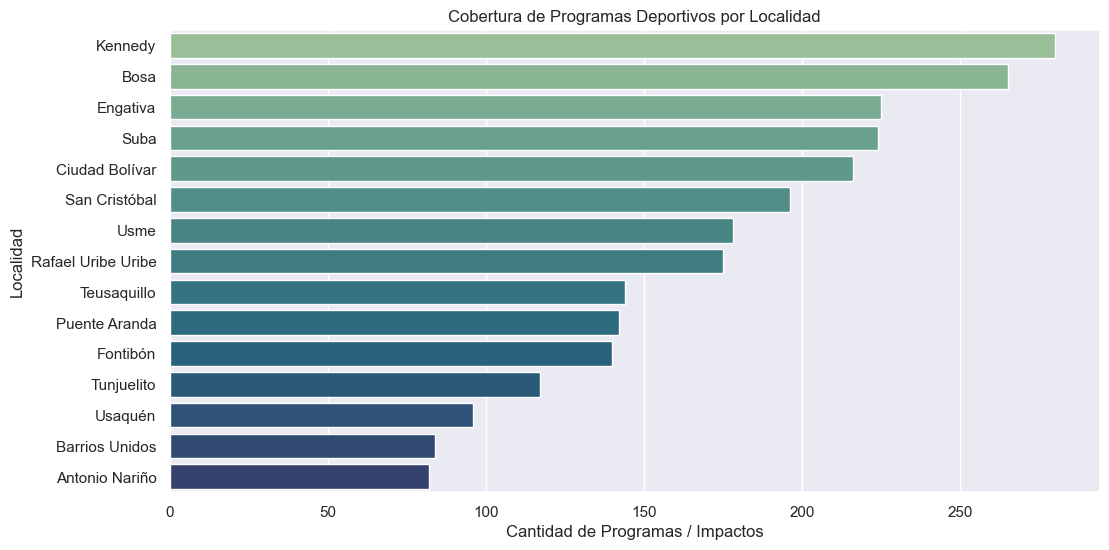

In [9]:
# Buscar columna de localidad dinámicamente
col_loc = [c for c in df_deporte.columns if 'localidad' in str(c).lower()]
if col_loc:
    loc_name = col_loc[0]
    conteo_prog = df_deporte[loc_name].value_counts().head(15)
    plt.figure(figsize=(12,6))
    sns.barplot(x=conteo_prog.values, y=conteo_prog.index, palette='crest')
    plt.title('Cobertura de Programas Deportivos por Localidad')
    plt.xlabel('Cantidad de Programas / Impactos')
    plt.ylabel('Localidad')
    plt.show()

## 👥 Enfoque y 📊 Intensidad
**¿Están dirigidos a jóvenes? ¿Cantidad de programas por zona?**

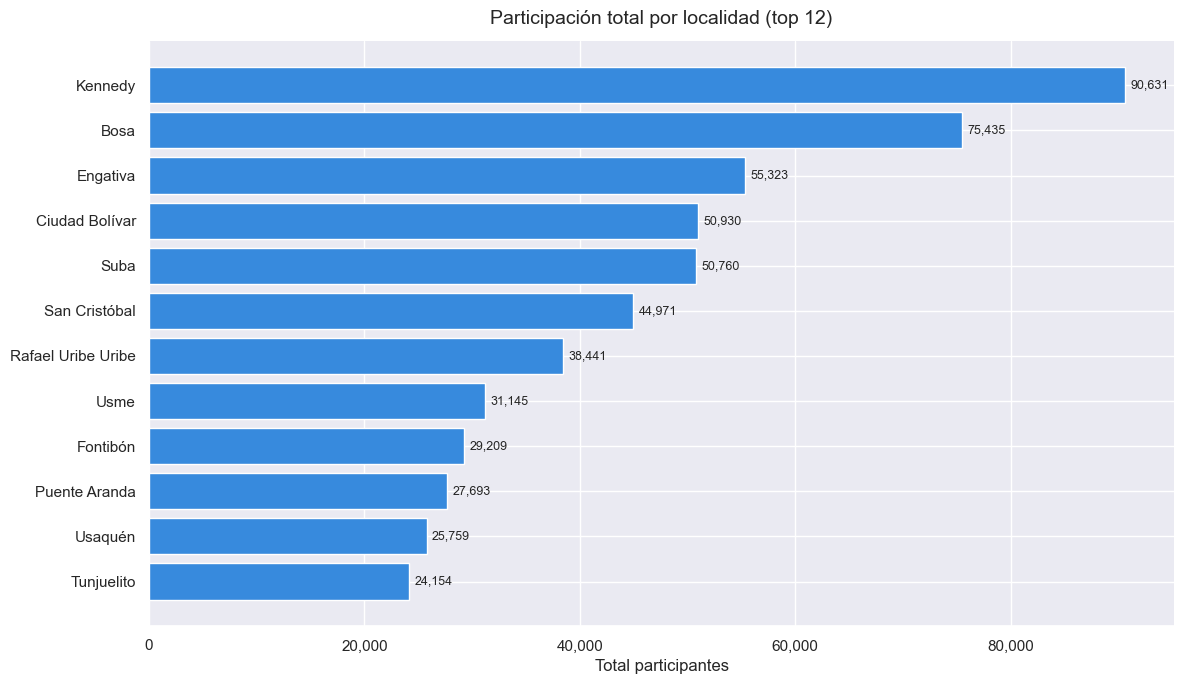

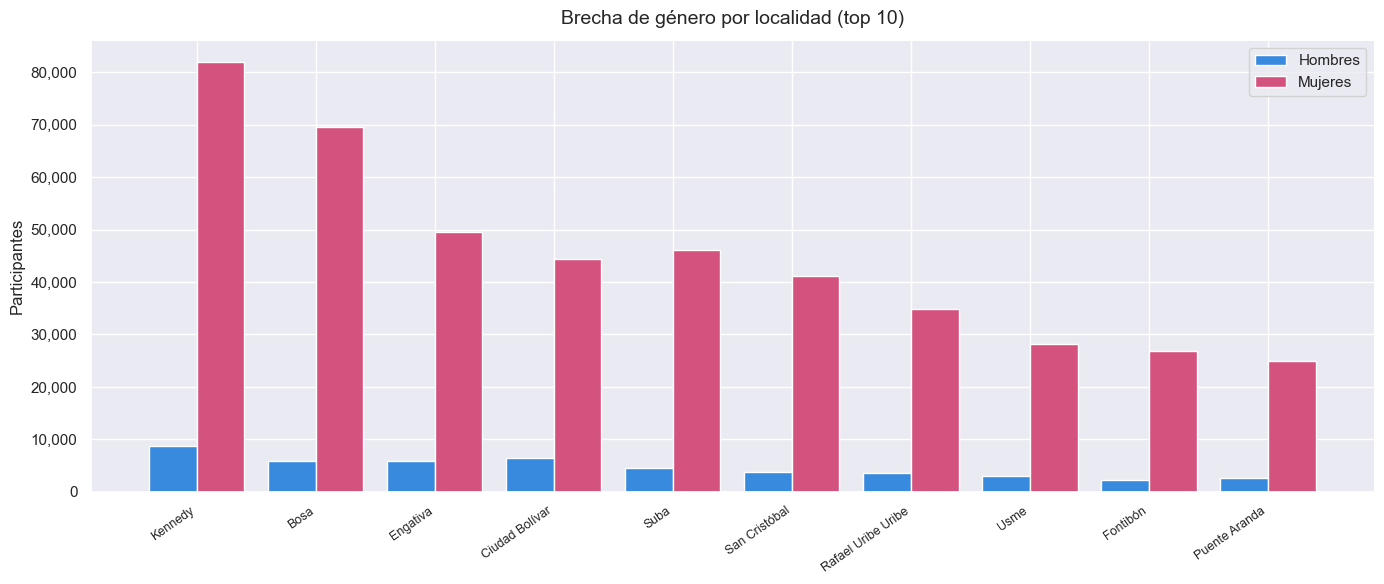

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

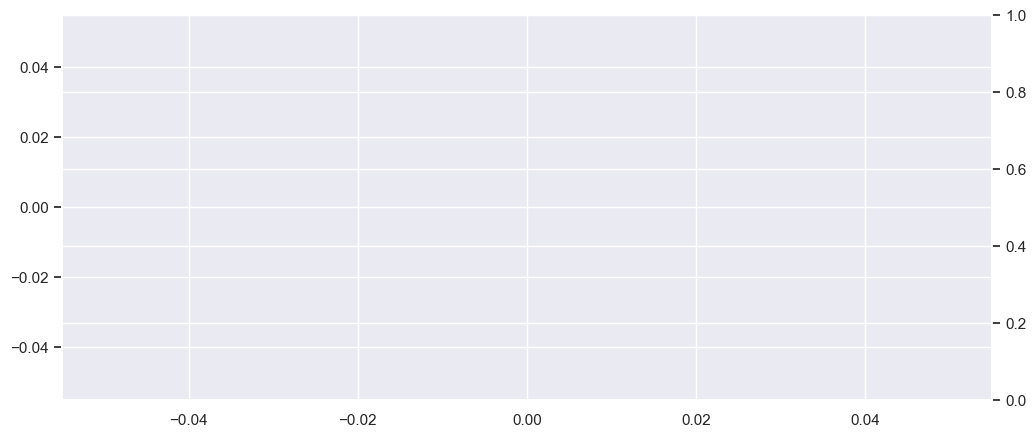

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# ── 1. PARTICIPACIÓN TOTAL POR LOCALIDAD (top 12) ──────────────────────────
por_localidad = (
    df_deporte.groupby('localidad')[['participanteshombres','participantesmujeres','total']]
    .sum()
    .sort_values('total', ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(por_localidad.index, por_localidad['total'], color='#378ADD')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_title('Participación total por localidad (top 12)', fontsize=14, pad=12)
ax.set_xlabel('Total participantes')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()


# ── 2. BRECHA DE GÉNERO POR LOCALIDAD ──────────────────────────────────────
top10 = por_localidad.head(10)
x = np.arange(len(top10))
w = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, top10['participanteshombres'], width=w, label='Hombres', color='#378ADD')
ax.bar(x + w/2, top10['participantesmujeres'], width=w, label='Mujeres', color='#D4537E')
ax.set_xticks(x)
ax.set_xticklabels(top10.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Brecha de género por localidad (top 10)', fontsize=14, pad=12)
ax.set_ylabel('Participantes')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()


# ── 3. ACTIVIDADES Y PARTICIPANTES POR MES ─────────────────────────────────
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

por_mes = (
    df_deporte.groupby('mes')
    .agg(participantes=('total','sum'), actividades=('#_actividades','sum'))
    .reindex([m for m in orden_meses if m in df_deporte['mes'].unique()])
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(por_mes.index, por_mes['participantes'], marker='o', color='#1D9E75', linewidth=2.5, label='Participantes')
ax1.fill_between(por_mes.index, por_mes['participantes'], alpha=0.12, color='#1D9E75')
ax2.plot(por_mes.index, por_mes['actividades'], marker='s', color='#EF9F27', linewidth=2, linestyle='--', label='Actividades')

ax1.set_ylabel('Participantes', color='#1D9E75')
ax2.set_ylabel('Actividades', color='#EF9F27')
ax1.set_title('Participantes y actividades por mes', fontsize=14, pad=12)
ax1.tick_params(axis='x', rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
sns.despine(right=False)
plt.tight_layout()
plt.show()